In [87]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl
import torch

from autoencoder.model import Autoencoder
from eval.openclip_encoder import OpenCLIPNetwork

## Config

In [88]:
# for hypernerf data dirs
data_root = Path("data/hypernerf/chickchicken")
rgb_root = data_root / "rgb/2x"
lang_root = data_root / "clip_features"

queries = [
    "hand", "chicken"
]
neutral_corpus = [
    "object",
    "things",
    "stuff",
    "texture"
]

ae_path = Path("autoencoder/ckpt/chickchicken_clip/best_ckpt.pth")

sam_level = 3

## Load samples, add ae features

In [ ]:
sample_names = [i.stem for i in sorted(rgb_root.glob("*.png"))]
samples = {}
for sample_name in sample_names[::10]: #! every 10th
    rgb_path = rgb_root / f"{sample_name}.png"
    seg_path = lang_root / f"{sample_name}_s.npy"
    lfs_path = lang_root / f"{sample_name}_f.npy"

    rgb = np.array(Image.open(rgb_path).convert("RGB"))
    segmentation_map = np.load(seg_path)[sam_level].astype(np.int32)
    feat = np.load(lfs_path)

    samples[sample_name] = {
        "rgb": rgb,
        "seg": segmentation_map,
        "feat": feat
    }

In [114]:
ae = Autoencoder(
    encoder_hidden_dims=[256, 128, 64, 32, 3],
    decoder_hidden_dims=[16, 32, 64, 128, 256, 512],
    feature_dim=512,
).to("cuda")
ae.load_state_dict(torch.load(ae_path, map_location="cuda"))
ae.eval()

with torch.no_grad():
    for sample in samples.values():
        f = torch.tensor(sample["feat"]).to("cuda")
        f_rec = ae.decode(ae.encode(f))
        sample["feat_rec"] = f_rec.detach().cpu().numpy()
        print((f - f_rec).norm(dim=-1).mean())


tensor(0.3712, device='cuda:0')
tensor(0.3279, device='cuda:0')
tensor(0.3220, device='cuda:0')
tensor(0.3101, device='cuda:0')
tensor(0.3217, device='cuda:0')
tensor(0.3000, device='cuda:0')
tensor(0.2978, device='cuda:0')
tensor(0.3074, device='cuda:0')
tensor(0.3396, device='cuda:0')
tensor(0.3045, device='cuda:0')
tensor(0.2986, device='cuda:0')
tensor(0.3098, device='cuda:0')
tensor(0.3483, device='cuda:0')
tensor(0.3182, device='cuda:0')
tensor(0.3040, device='cuda:0')
tensor(0.2903, device='cuda:0')
tensor(0.3160, device='cuda:0')
tensor(0.2960, device='cuda:0')
tensor(0.2983, device='cuda:0')
tensor(0.2966, device='cuda:0')
tensor(0.3078, device='cuda:0')
tensor(0.3309, device='cuda:0')
tensor(0.2971, device='cuda:0')
tensor(0.2931, device='cuda:0')
tensor(0.2940, device='cuda:0')
tensor(0.2990, device='cuda:0')
tensor(0.3073, device='cuda:0')
tensor(0.3299, device='cuda:0')
tensor(0.2929, device='cuda:0')
tensor(0.2690, device='cuda:0')
tensor(0.2803, device='cuda:0')
tensor(0

## Viz helper

In [116]:
def corr_plot_different_queries(correspondence_scores, segmentation_map, corr_min = 0.0, corr_max = 1.0, cmap = 'seismic', prefix = ""):
    norm = mcolors.Normalize(vmin=corr_min, vmax=corr_max, clip=True)
    cmap = mpl.colormaps[cmap]

    ncols = min(2, len(queries))
    nrows = int(np.ceil(len(queries) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), dpi=150)
    axes = np.atleast_1d(axes).ravel()
    used_axes = axes[:len(queries)]

    # show grid of images with corresponding text
    for i, q in enumerate(queries):
        feat_corr = correspondence_scores[i]
        feat_rgba = cmap(norm(feat_corr))
        feat_rgb = (feat_rgba[:, :3] * 255.0).astype(np.uint8)

        # segmentation map is -1 for background to n_feats - 1
        feat_img = np.zeros((*segmentation_map.shape, 3), dtype=np.uint8)
        for j, col in enumerate(feat_rgb):
            feat_img[segmentation_map == j] = col

        ax = axes[i]
        ax.imshow(feat_img)
        ax.set_title(prefix + " " + q)

    # hide any unused axes
    for ax in axes[len(queries):]:
        ax.axis('off')

    # increase spacing/borders between subplots
    fig.subplots_adjust(wspace=0.35, hspace=0.35)

    # add a shared colorbar (legend) for cosine similarity
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=used_axes, fraction=0.046, pad=0.04)

    plt.show()

## LERF Relevance Scores

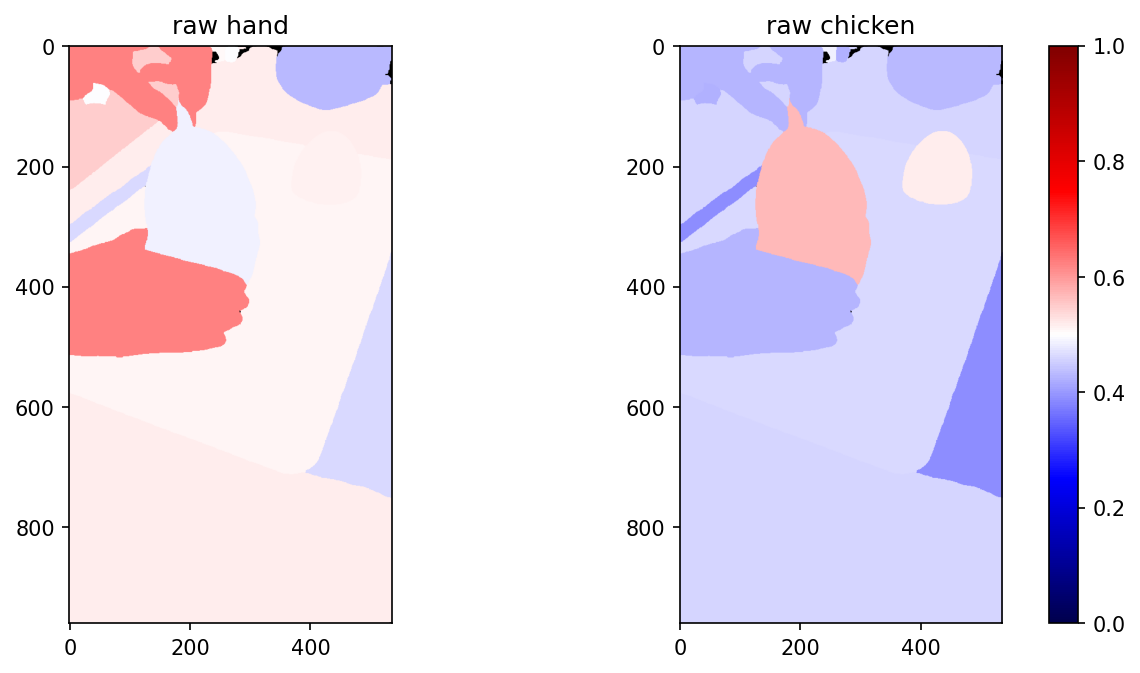

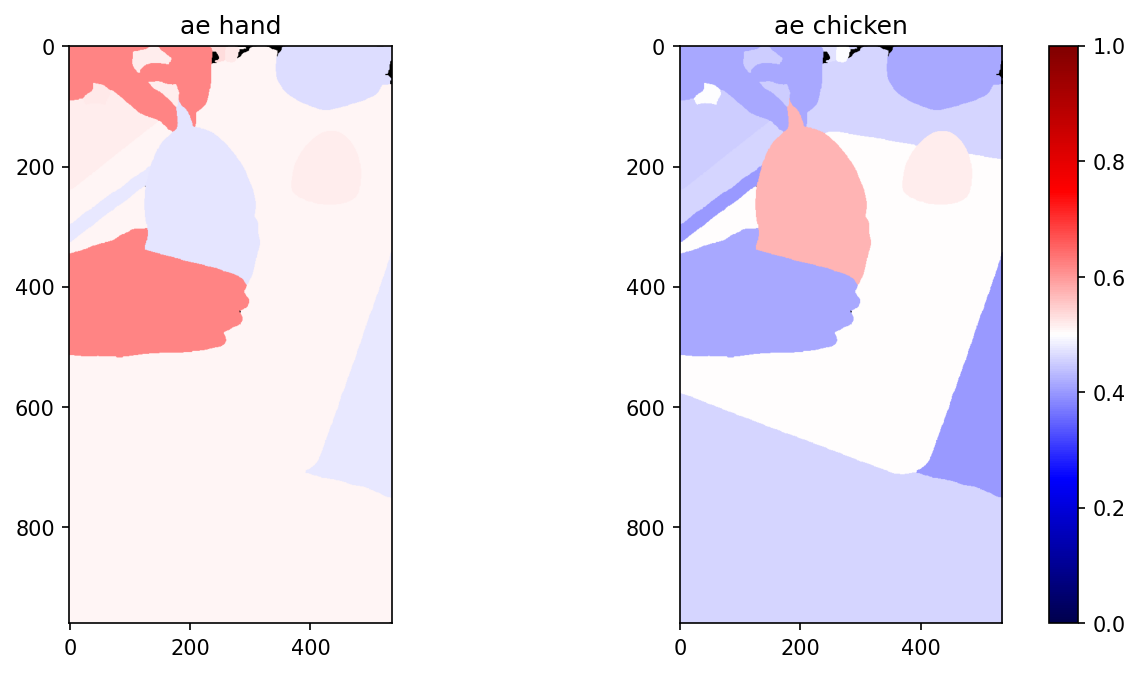

In [121]:
sample = list(samples.values())[40]

ocn = OpenCLIPNetwork(device="cuda")
ocn.set_positives(queries)

# before AE
lerf_relevancies = []
f = torch.tensor(sample["feat"]).to("cuda")
f = f / f.norm(dim=-1, keepdim=True)
for i in range(len(queries)):
    r = ocn.get_relevancy(f, i)
    r = r[:, 0].detach().cpu().numpy()
    lerf_relevancies.append(r)
lerf_relevancies = np.stack(lerf_relevancies)

corr_plot_different_queries(lerf_relevancies, sample["seg"], prefix="raw")

# after AE
lerf_relevancies = []
f = torch.tensor(sample["feat_rec"]).to("cuda")
f = f / f.norm(dim=-1, keepdim=True)
for i in range(len(queries)):
    r = ocn.get_relevancy(f, i)
    r = r[:, 0].detach().cpu().numpy()
    lerf_relevancies.append(r)
lerf_relevancies = np.stack(lerf_relevancies)

corr_plot_different_queries(lerf_relevancies, sample["seg"], prefix="ae")

## AE Aggregation

In [132]:
for sample in samples.values():
    sq = sample["feat"] ** 2
    mean_norm = ((sq @ sq.T) ** 0.5).mean()
    print(mean_norm)

for sample in samples.values():
    # mean reconstuction error when passed through enc + dec individually
    mean_dist_individual = np.linalg.norm(sample["feat"] - sample["feat_rec"], axis=-1).mean()

    # rec error when aggregated feature is passed through enc + dec
    mean_feat = sample["feat"].mean(axis=0, keepdims=True)
    mean_feat_rec = ae.decode(ae.encode(torch.tensor(mean_feat).to("cuda"))).detach().cpu().numpy()
    mean_dist_ae = np.linalg.norm(mean_feat - mean_feat_rec, axis=-1)

    # mean rec error when aggregating in latent space
    latents = ae.encode(torch.tensor(sample["feat"]).to("cuda"))
    mean_latent = latents.mean(axis=0, keepdims=True)
    mean_latent_rec = ae.decode(mean_latent).detach().cpu().numpy()
    mean_dist_latent = np.linalg.norm(mean_feat - mean_latent_rec, axis=-1)

    print(mean_dist_individual, mean_dist_ae.item(), mean_dist_latent.item())


0.30544335
0.3002684
0.30670983
0.31186476
0.30492625
0.3009975
0.29740828
0.30731782
0.3069699
0.30849373
0.2987966
0.30307192
0.30495548
0.30255485
0.29729864
0.30192325
0.3064576
0.3026044
0.30775574
0.30536616
0.3031201
0.29334205
0.29200527
0.30453095
0.3066703
0.29777393
0.29865065
0.3028707
0.2971146
0.29351997
0.30458224
0.30010843
0.30488917
0.30091813
0.3042991
0.31050995
0.30397448
0.2921223
0.30668992
0.30123702
0.30882716
0.30505702
0.29574245
0.3069397
0.30835268
0.30250004
0.3711549 0.3688179850578308 0.38479071855545044
0.32793158 0.369399756193161 0.4247834384441376
0.32200414 0.4213586449623108 0.49676766991615295
0.31007963 0.40045133233070374 0.4783627986907959
0.32169083 0.3882007896900177 0.43584081530570984
0.29995373 0.39875492453575134 0.48143336176872253
0.2977683 0.4265262186527252 0.5246720314025879
0.3074219 0.4173162877559662 0.48658251762390137
0.3395615 0.39887574315071106 0.4419619143009186
0.30452898 0.46338629722595215 0.49380818009376526
0.29856563 0

## Plain Cosine Similarity

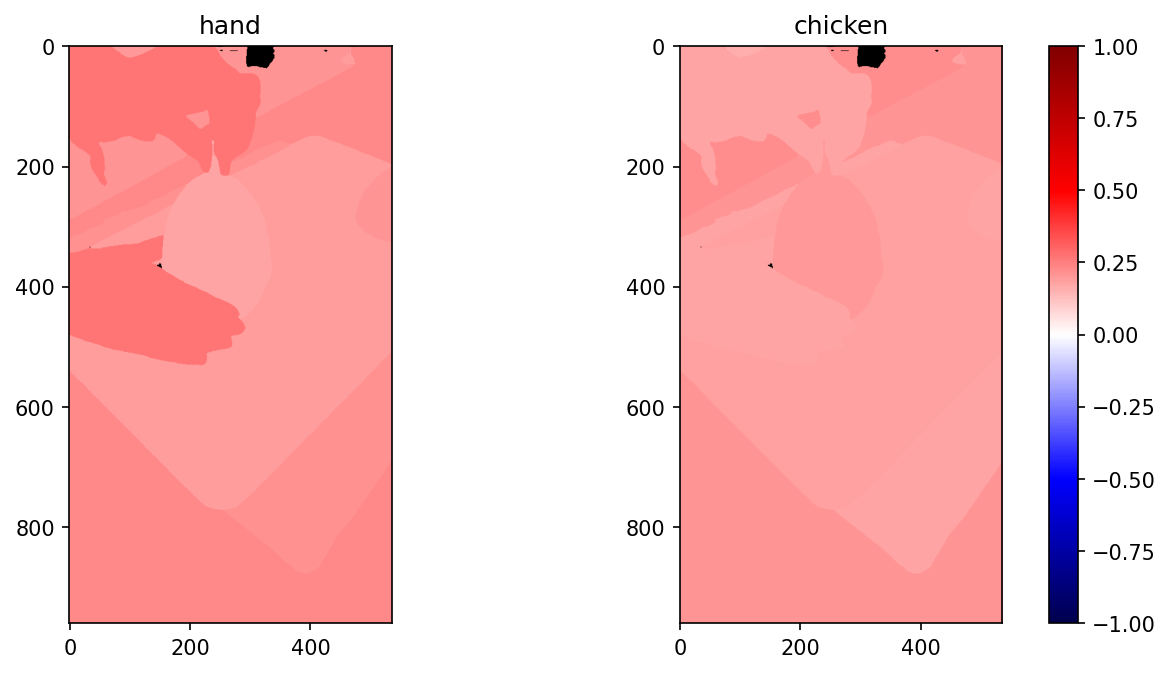

In [110]:
sample = list(samples.values())[10]
ocn = OpenCLIPNetwork(device="cuda")
ocn.set_positives(queries)
query_feats = ocn.pos_embeds.cpu().numpy()
f = sample["feat"] / np.linalg.norm(sample["feat"], axis=-1, keepdims=True)
cos_sims = query_feats @ f.T

corr_plot_different_queries(cos_sims, sample["seg"], corr_min=-1.0, corr_max=1.0)

In [ ]:
## Check if autoencoder breaks them
ae = Autoencoder(
    encoder_hidden_dims=[256, 128, 64, 32, 3],
    decoder_hidden_dims=[16, 32, 64, 128, 256, 512],
    feature_dim=512,
).to("cuda")
ae.load_state_dict(torch.load(ae_path, map_location="cuda"))
ae.eval()

In [ ]:
with torch.no_grad():
    f = torch.tensor(sample["feat"]).to("cuda")
    f_rec = ae.decode(ae.encode(f))
    f_rec = f_rec / f_rec.norm(dim=-1, keepdim=True)
    